# Agrupación (Clustering): Comportamiento diario de la acción de Samsung
## Marco Antonio Ortega Reséndiz

Objetivo: Agrupar los días de operación según su comportamiento de mercado (rendimiento diario, volatilidad y volumen relativo), para identificar regímenes de mercado

## 1. Justificación del algoritmo

Se eligió K-Means porque:
- Es el algoritmo de clustering más usado y sencillo de interpretar cuando se busca segmentar observaciones en grupos con comportamiento similar.
- Funciona muy bien con variables numéricas continuas y bien escaladas, como las que construimos aquí (rendimiento, volatilidad, volumen).


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
import joblib

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (8,5)


#### Carga y exploración de datos

In [3]:
df = pd.read_csv('C:/Users/style/Downloads/SA_datos/samsung.csv')
df['Date'] = pd.to_datetime(df['Date'], format='%d/%m/%Y')
df = df.sort_values('Date').reset_index(drop=True)
print(df.shape)
df.head()


(2850, 3)


,Date,Close,Volume
0,2008-01-02,10880,18047200
1,2008-01-03,10920,19346500
2,2008-01-04,10780,17997350
3,2008-01-07,10380,39787200
4,2008-01-08,10320,24783700


In [4]:
df.describe()

,Date,Close,Volume
count,2850,2850.000000,2.850000e+03
mean,2013-09-12 15:43:49.894736,26611.305263,1.610505e+07
min,2008-01-02 00:00:00,8040.000000,0.000000e+00
25%,2010-10-25 06:00:00,16300.000000,1.021426e+07
50%,2013-09-02 12:00:00,25600.000000,1.359033e+07
75%,2016-07-26 18:00:00,30850.000000,1.960970e+07
max,2019-06-28 00:00:00,57220.000000,6.487345e+07
std,NaN,11991.608543,8.661794e+06


#### Diseño del modelo: ingeniería de variables

Construimos variables que describen comportamiento del día (no el nivel absoluto del precio, que solo crece con el tiempo):
- `rendimiento`: variación porcentual diaria del precio de cierre.
- `volatilidad_5d`: desviación estándar del rendimiento en una ventana móvil de 5 días (qué tan "agitado" está el mercado).
- `volumen_relativo`: volumen del día dividido entre el promedio móvil de 20 días (si hoy se operó más o menos de lo normal).

In [5]:
df['rendimiento'] = df['Close'].pct_change() * 100
df['volatilidad_5d'] = df['rendimiento'].rolling(5).std()
df['volumen_relativo'] = df['Volume'] / df['Volume'].rolling(20).mean()

df_modelo = df.dropna().reset_index(drop=True)
print(df_modelo.shape)
df_modelo[['Date','rendimiento','volatilidad_5d','volumen_relativo']].head()


(2831, 6)


,Date,rendimiento,volatilidad_5d,volumen_relativo
0,2008-01-29,3.525046,2.932629,0.720754
1,2008-01-30,2.329749,3.004278,1.166035
2,2008-01-31,4.203152,3.232935,1.459323
3,2008-02-01,-1.512605,3.496820,0.870635
4,2008-02-04,4.436860,2.438563,1.425252


#### Gráfica de dispersión: comportamiento de los datos

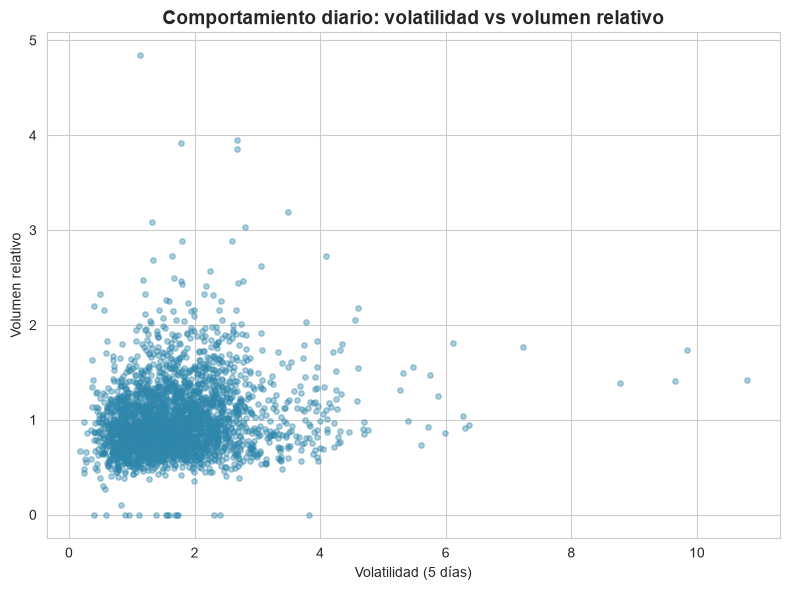

In [6]:
fig, ax = plt.subplots(figsize=(8,6))
ax.scatter(df_modelo['volatilidad_5d'], df_modelo['volumen_relativo'], s=15, alpha=0.4, color='#2E86AB')
ax.set_xlabel('Volatilidad (5 días)')
ax.set_ylabel('Volumen relativo')
ax.set_title('Comportamiento diario: volatilidad vs volumen relativo', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('scatter_comportamiento.png', dpi=120)
plt.show()


La mayoría de los días se concentran en volatilidad y volumen bajos-medios (mercado normal), con una cola de días de alta volatilidad y/o alto volumen (eventos atípicos, noticias, crisis). Esta forma de nube sugiere que sí existen grupos naturales de comportamiento distinto.

#### Escalamiento de variables

In [7]:
features = ['rendimiento', 'volatilidad_5d', 'volumen_relativo']
X = df_modelo[features]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print('Datos escalados, media ~0 y desviación ~1:')
print(pd.DataFrame(X_scaled, columns=features).describe().round(2))


Datos escalados, media ~0 y desviación ~1:
       rendimiento  volatilidad_5d  volumen_relativo
count      2831.00         2831.00           2831.00
mean          0.00           -0.00              0.00
std           1.00            1.00              1.00
min          -7.94           -1.77             -2.62
25%          -0.58           -0.67             -0.65
50%          -0.04           -0.17             -0.20
75%           0.55            0.45              0.45
max           6.88           10.48             10.04


#### Optimización: método del codo y coeficiente de silueta

Probamos distintos valores de k (número de clusters) para elegir el más adecuado.

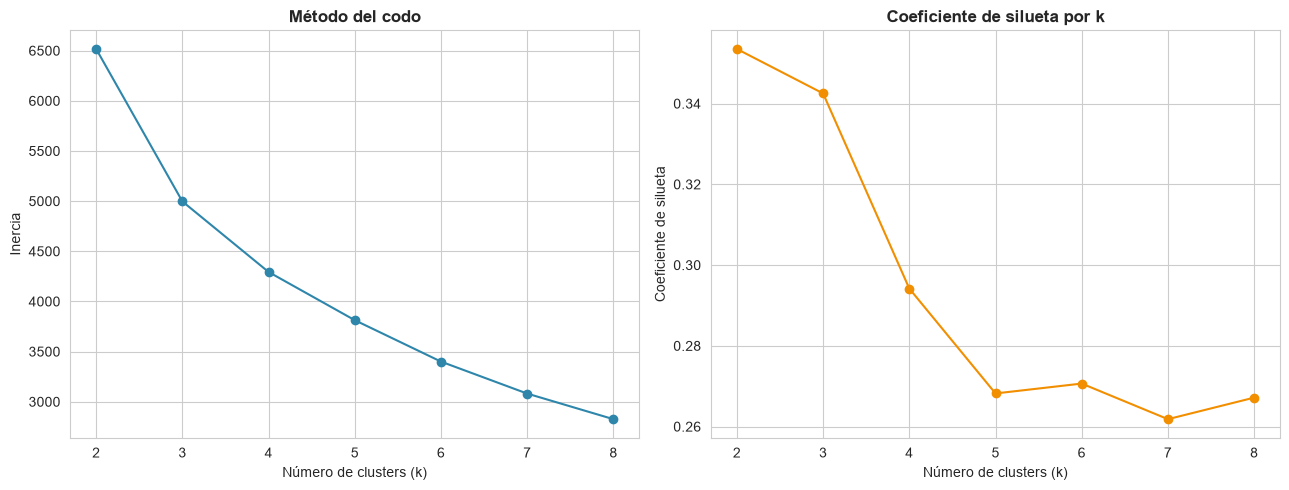

k=2: silueta=0.354
k=3: silueta=0.343
k=4: silueta=0.294
k=5: silueta=0.268
k=6: silueta=0.271
k=7: silueta=0.262
k=8: silueta=0.267


In [8]:
inercias = []
siluetas = []
rango_k = range(2, 9)

for k in rango_k:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inercias.append(km.inertia_)
    siluetas.append(silhouette_score(X_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(13,5))
axes[0].plot(list(rango_k), inercias, marker='o', color='#2E86AB')
axes[0].set_xlabel('Número de clusters (k)')
axes[0].set_ylabel('Inercia')
axes[0].set_title('Método del codo', fontweight='bold')

axes[1].plot(list(rango_k), siluetas, marker='o', color='#F18F01')
axes[1].set_xlabel('Número de clusters (k)')
axes[1].set_ylabel('Coeficiente de silueta')
axes[1].set_title('Coeficiente de silueta por k', fontweight='bold')

plt.tight_layout()
plt.savefig('codo_silueta.png', dpi=120)
plt.show()

for k, s in zip(rango_k, siluetas):
    print(f'k={k}: silueta={s:.3f}')


La inercia baja fuertemente de k=2 a k=3 y luego la caída se suaviza (codo alrededor de k=3). El coeficiente de silueta es máximo en k=2 (0.354) pero muy cercano en k=3 (0.343); a partir de k=4 baja de forma más notoria. 

#### Entrenamiento del modelo final

In [9]:
k_optimo = 3
modelo_final = KMeans(n_clusters=k_optimo, random_state=42, n_init=10)
df_modelo['cluster'] = modelo_final.fit_predict(X_scaled)

sil_final = silhouette_score(X_scaled, df_modelo['cluster'])
print(f'Silueta final (k={k_optimo}): {sil_final:.3f}')
print()
print(df_modelo.groupby('cluster')[features].mean().round(2))
print()
print(df_modelo['cluster'].value_counts().sort_index())


Silueta final (k=3): 0.343

         rendimiento  volatilidad_5d  volumen_relativo
cluster                                               
0              -2.25            2.14              1.35
1               0.05            1.35              0.83
2               2.51            2.51              1.22

cluster
0     528
1    1785
2     518
Name: count, dtype: int64


#### Gráfica comparativa: clusters obtenidos (PCA 2D)

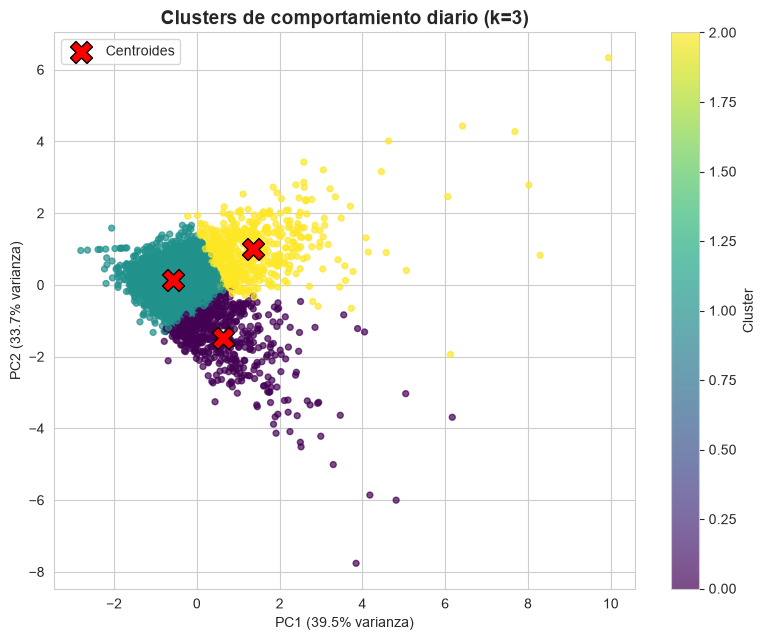

In [10]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

fig, ax = plt.subplots(figsize=(8,6.5))
scatter = ax.scatter(X_pca[:,0], X_pca[:,1], c=df_modelo['cluster'], cmap='viridis', s=18, alpha=0.7)
centros_pca = pca.transform(modelo_final.cluster_centers_)
ax.scatter(centros_pca[:,0], centros_pca[:,1], c='red', marker='X', s=250, edgecolor='black', label='Centroides')
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% varianza)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% varianza)')
ax.set_title(f'Clusters de comportamiento diario (k={k_optimo})', fontsize=14, fontweight='bold')
ax.legend()
plt.colorbar(scatter, label='Cluster')
plt.tight_layout()
plt.savefig('clusters_pca.png', dpi=120)
plt.show()


Los 2 componentes principales capturan la mayor parte de la varianza de las 3 variables originales. Se observan grupos bien diferenciados: un cluster grande de días normales (baja volatilidad/volumen) y clusters más pequeños de días atípicos (alta volatilidad y/o alto volumen), que probablemente correspondan a eventos de mercado relevantes (ej. crisis 2008, caídas fuertes).

#### Gráfica adicional: evolución temporal de los clusters

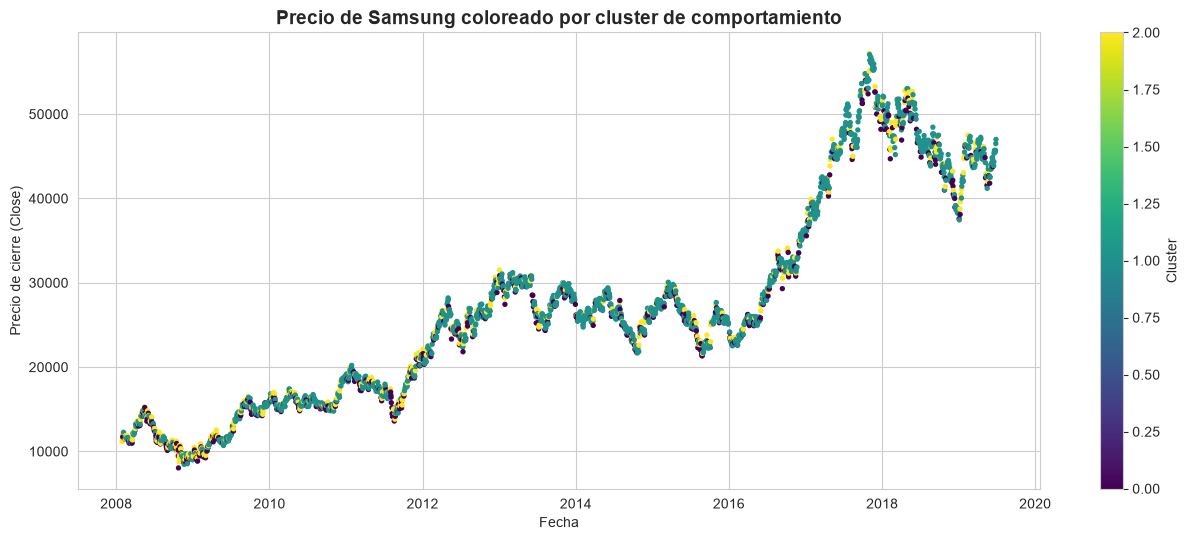

In [11]:
fig, ax = plt.subplots(figsize=(13,5.5))
scatter = ax.scatter(df_modelo['Date'], df_modelo['Close'], c=df_modelo['cluster'], cmap='viridis', s=8)
ax.set_xlabel('Fecha')
ax.set_ylabel('Precio de cierre (Close)')
ax.set_title('Precio de Samsung coloreado por cluster de comportamiento', fontsize=14, fontweight='bold')
plt.colorbar(scatter, label='Cluster')
plt.tight_layout()
plt.savefig('clusters_tiempo.png', dpi=120)
plt.show()


Al ver los clusters sobre la línea de tiempo del precio, los días de comportamiento atípico (alta volatilidad/volumen) tienden a concentrarse en periodos de crisis o cambios fuertes de tendencia, mientras que los periodos de crecimiento estable quedan en el cluster de comportamiento 'normal'.

#### Guardado 

In [12]:
joblib.dump({'modelo': modelo_final, 'scaler': scaler, 'features': features}, 'modelo_samsung_clustering.pkl')
print('Modelo guardado como modelo_samsung_clustering.pkl')


Modelo guardado como modelo_samsung_clustering.pkl
